# 1. Star catalogues

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import patches, ticker
from matplotlib.ticker import FuncFormatter
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 
from shapely.geometry import Point, Polygon

# PlatoSim libraries
import platosim.plot      as pt
import platosim.starquery as sq
import platosim.utilities as ut
import platosim.mocka     as mk
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper(warning=False)

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [3]:
# Define paths used throughout
path = '/lhome/nicholas/software/workdir/mocka'
vdir = f'{path}/vizier'
idir = f'{path}/input'
pdir = f'{path}/plots'
fdir = f'{path}/figures'

# Use seed for reproducebility
seed = 12345
rng = ut.rng(seed)

---
## Stellar catalgue using Gaia DR3
---

The following steps was done to generate a PLATO LOPS2 Gaia DR3 catalogue:

- First a LOPS2 Gaia DR3 catalogue was generated with the `picsim --vizier` query method. The stellar catiologue is complete for Gmag < 18 mag (i.e. around Pmag < 18.5).
- Full-frame images of each CCD for N-CAM 1.1, 2.1, 3.1, and 4.1 were generated with `platonium --fullframe` simulation method. This way we can discard all stars that undetecable (i.e. outside FOV, ouside the CCDs, or in a CCD gap). Below we load and combine a new catalogue with updated information. 
- In the following we show the full-frame CCD simulations and generate the main catalogue to be used by `varsim` and `platonium`.

In [ ]:
# PLOT FOR PAPER: FULL-FRAME IMAGE OF CCD4:
#------------------------------------------
# Select a desired group
group, cam = 4, 1
f1 = SimFile(f'{vdir}/Ncam{group}.{cam}_Q1_ccd1.hdf5')
f2 = SimFile(f'{vdir}/Ncam{group}.{cam}_Q1_ccd2.hdf5')
f3 = SimFile(f'{vdir}/Ncam{group}.{cam}_Q1_ccd3.hdf5')
f4 = SimFile(f'{vdir}/Ncam{group}.{cam}_Q1_ccd4.hdf5')

# Fetch CCD images
im1 = f1.getImage(0)
im2 = f2.getImage(0)
im3 = f3.getImage(0)
im4 = f4.getImage(0)

# Plot FPA in a subplot
fig = plt.figure(figsize=(9,9))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

axs = [ax1, ax2, ax3, ax4]
ims = [im1, im4, im2, im3]
ang = [180,  270,  90,  0]

for ax, im, a in zip(axs, ims, ang):
    
    im = ut.imageNorm(im, "log", sigma=0.3)
    vmin = im.min()
    vmax = im.max()
    norm = 'linear'

    ax.imshow(sp.ndimage.rotate(im, a), norm=norm, origin='lower')
    ax.xaxis.set_ticks([])
    ax.yaxis.set_ticks([])
    
plt.tight_layout(pad=0)
fig.savefig(f'{fdir}/full_frame_image_group4.png', bbox_inches='tight', dpi=200)

In [ ]:
# Load full-frame stellar catalogues
group, cam = 1, 1
df11 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd1.ftr")
df12 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd2.ftr")
df13 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd3.ftr")
df14 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd4.ftr")
group, cam = 2, 1
df21 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd1.ftr")
df22 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd2.ftr")
df23 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd3.ftr")
df24 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd4.ftr")
group, cam = 3, 1
df31 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd1.ftr")
df32 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd2.ftr")
df33 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd3.ftr")
df34 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd4.ftr")
group, cam = 4, 1
df41 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd1.ftr")
df42 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd2.ftr")
df43 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd3.ftr")
df44 = pd.read_feather(f"{vdir}/Ncam{group}.{cam}_Q1_ccd4.ftr")

# Combine all CCD catalogue into one
df = pd.concat([df11, df12, df13, df14, df21, df22, df23, df24,
                df31, df32, df33, df34, df41, df42, df43, df44])

# Drop a few columns
df = df.drop(columns=['xCCD', 'yCCD', 'xFP', 'yFP', 'rOA'])

# Sort after gaia DR3
df = df.sort_values(by=['gaiaDR3'])

In [ ]:
# Fetch N-CAM group visibility
N = df.shape[0]
ncams = np.zeros(N)

for i in tqdm(range(N), bar_format=ut.tqdmBar()):

    # Fetch 4 values ahead (since max 4 groups)
    dx = df.iloc[i:i+4]
    
    # Subtract star ID and count zeros = N-CAM visibility:
    # Row with highest ncams value is the one we keep below
    diff = np.array(dx.gaiaDR3).astype(int) - int(dx.gaiaDR3.iloc[0])
    ncams[i] = np.count_nonzero(diff==0)
    
# Add column 
df['ncams'] = (ncams * 6).astype(int)

In [ ]:
# Drop dublicates and keep highest count
df = df.drop_duplicates(subset=['gaiaDR3'])

# Check that all stars have a defined colour
df.BP_RP.isna().sum()

In [ ]:
# Sort after ncams and Pmag
df0 = df.sort_values(by=['ncams', 'Pmag'])

# Save catalogue be used by varsim
df0.reset_index(drop=True, inplace=True)
df0.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS.ftr')

In [ ]:
# PLOT FOR PAPER: THE PLATO SKY FOV WITH DENSITY MAP:
#----------------------------------------------------
df0 = df.iloc[::1]
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=None, decStars=None,
                          system="icrs", showGroups=True, showLegend=False, ncamStars=df0, 
                          fovSize=30, fs=20, ms=1, figsize=(8,8))

# Plot dark contour
starPF = SkyCoord(df0.ra*u.deg, df0.dec*u.deg, frame='icrs', unit='deg')
scatter = ax.scatter(starPF.ra.deg, starPF.dec.deg, transform=ax.get_transform('world'),
                     s=2, alpha=0.01, marker='.', c='k', ec='none', zorder=5)

# Plot LMC pointing
lmc = SkyCoord(79.8917*u.deg, -68.7511*u.deg, frame='icrs', unit='deg')
plt.text(lmc.ra.deg-7, lmc.dec.deg+5, 'LMC', size=17, transform=ax.get_transform('world'))
ax.scatter(lmc.ra.deg, lmc.dec.deg, s=7e3, marker='o', edgecolor='orange', facecolor='none', 
           linewidth=1.5, transform=ax.get_transform('world'), zorder=6)

# M79
oc = SkyCoord(81.0441250*u.deg, -24.5242500*u.deg, frame='icrs', unit='deg')
plt.text(oc.ra.deg+2, oc.dec.deg+0.6, 'M79', size=17, transform=ax.get_transform('world'))
ax.scatter(oc.ra.deg, oc.dec.deg, s=50, marker='o', edgecolor='deeppink', facecolor='none', 
           linewidth=1.5, transform=ax.get_transform('world'), zorder=6)

# NGC2296
oc = SkyCoord(102.2475417*u.deg, -36.0053056*u.deg, frame='icrs', unit='deg')
plt.text(oc.ra.deg+3.4, oc.dec.deg+1.2, 'N2296', size=17, transform=ax.get_transform('world'))
ax.scatter(oc.ra.deg, oc.dec.deg, s=50, marker='o', edgecolor='deeppink', facecolor='none', 
           linewidth=1.5, transform=ax.get_transform('world'), zorder=6)

# NGC1851
oc = SkyCoord(78.5281667*u.deg, -40.0465556*u.deg, frame='icrs', unit='deg')
plt.text(oc.ra.deg+3.8, oc.dec.deg+0.7, 'N1851', size=17, transform=ax.get_transform('world'))
ax.scatter(oc.ra.deg, oc.dec.deg, s=50, marker='o', edgecolor='deeppink', facecolor='none', 
           linewidth=1.5, transform=ax.get_transform('world'), zorder=6)

# E1
oc = SkyCoord(58.7604167*u.deg, -49.6144444*u.deg, frame='icrs', unit='deg')
plt.text(oc.ra.deg+2, oc.dec.deg+0.3, 'E1', size=17, transform=ax.get_transform('world'))
ax.scatter(oc.ra.deg, oc.dec.deg, s=50, marker='o', edgecolor='deeppink', facecolor='none', 
           linewidth=1.5, transform=ax.get_transform('world'), zorder=6)

# Plot N-CAM visibility
box4 = fig.text(0.385, 0.515, '24', fontsize=20)
box3 = fig.text(0.353, 0.400, '18', fontsize=20)
box2 = fig.text(0.340, 0.340, '12', fontsize=20)
box1 = fig.text(0.315, 0.225, '6',  fontsize=20)
box1.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box2.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box3.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box4.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))

# Save figure
fig.savefig(f'{fdir}/LOPS2.png', bbox_inches='tight', dpi=200);

### Perform cuts and save Gaia-LOPS2 catalogue

In [ ]:
# Load original catalogue
df = pd.read_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_original.ftr')

# Remove stars with bad colour solutions
df.BP_RP.loc[df[(df.BP_RP == 2.000)].index] = np.nan

# Merge non-defined spectypes into the unknown spectype
df.spec.loc[df[df.spec == ''].index] = 'unknown'

# Add distances [pc]
df['d'] = 1 / (df.plx/1e3)

# Add absolute magnitude (no extinction correction)
df['Mg'] = df.Gmag - 5*np.log10(df.d) + 5

# Replace any inf with nan
df = df.replace(np.inf, np.nan)

# Seperate dwarfs from giants/compact objects
xlim0 = 0.8
xlim1 = 0.3
reqs0 = ((df.BP_RP > xlim0) & (df.Mg < mk.RG_upper(df.BP_RP))) 
reqs1 = ((df.BP_RP < xlim1) & (df.Mg > mk.WD_upper(df.BP_RP)) | 
         (df.BP_RP > xlim1) & (df.Mg > mk.WD_lower(df.BP_RP)))
dx0 = df[reqs0]
dx1 = df[reqs1]
df.Pmag.loc[dx0.index] = df.Pgiant.loc[dx0.index]
df.Pmag.loc[dx1.index] = df.Pgiant.loc[dx1.index]
# df['Pgiant'] = ut.passbandConversionG2P(df.Gmag, df.BP_RP, stage='giant')
df = df.drop(columns=['Pgiant'])
df = df.reset_index(drop=True)

# Save new catalogue
df.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS.ftr')

In [ ]:
# # Check location of bad colour solutions
# df = pd.read_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_original.ftr')
# df = df[(df.BP_RP == 2.000)]
# fig, ax = pt.plotPlatoFOV('LOPS2', raStars=df.ra, decStars=df.dec, c=df.Pmag, 
#                           ncamStars=True, clabel=r'$P$ [mag]', figsize=(9,9))

---
## CaMD and HRD
---

In [5]:
# Read main catalogue
df = pd.read_feather(f'{idir}/starcat_GaiaDR3_PlatoCS.ftr')
dc = pd.read_feather(f'{idir}/starcat_GaussianDensity.ftr')

# Print stars with and without extinction
print('Number of stars in total           :', df.shape[0])
print('Number of stars with    extinction :', df.dropna(subset=["Ag"]).shape[0])
print('Number of stars without extinction :', df[df.Ag.isna()].shape[0])
print('Number of potential binaries       :', df[df.ruwe > 1.2].shape[0])
print('Number of potential binaries       :', df[df.ruwe > 1.4].shape[0])

Number of stars in total           : 7757180
Number of stars with    extinction : 6602912
Number of stars without extinction : 1154268
Number of potential binaries       : 858359
Number of potential binaries       : 637250


In [ ]:
# Total number of stars after cuts
fig, ax = plt.subplots(1,1, figsize=(8,5))
order = ['O', 'B', 'A', 'F', 'G', 'K', 'M', 'unknown', 'CSTAR']
df.spec.value_counts().loc[order].plot.bar(rot=25)
ax.set_title(f'Total number of stars: {df.shape[0]}')
ax.set_xlabel('Spectral type')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

In [ ]:
# Binarity fraction of each spectral bin
fig, ax = plt.subplots(1,1, figsize=(8,5))
order = ['O', 'B', 'A', 'F', 'G', 'K', 'M', 'unknown', 'CSTAR']
dx0 = df.spec.value_counts().loc[order]
dx1 = df[df.ruwe > 1.2].spec.value_counts().loc[order]
(dx1/dx0).plot.bar(rot=25, color='r')
ax.set_title(f'Total number of stars: {df.shape[0]}')
ax.set_xlabel('Spectral type')
ax.set_ylabel('Binarity fraction')
plt.tight_layout();

In [ ]:
# Absolute magnitude (with extinction correction)
# df0 = df0.dropna(subset=['Ag'])
# df0['Mg'] = df0.Gmag - 5*np.log10(df0.d) + 5 - df0.Ag
# df0 = df0.replace(np.inf, np.nan)
# df0 = df0.dropna(subset=['Mg'])

df['d'] = 1e3 / df0.plx
df0['Mg'] = df0.Gmag - 5*np.log10(df0.d) + 5

# Cut in parallax
df1 = df0[df.plx > 1]  # < 1000 pc
df2 = df0[df.plx > 3]  # < 333 pc
df3 = df0[df.plx > 10] # < 100 pc

In [ ]:
dx = df0

# Inspect P magnitudes
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(dx.Pmag, bins=100)
ax.set_xlabel(r'PLATO magnitude, $P$')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()

# Inspect parallax
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(dx.plx, bins=100)
ax.set_xlabel(r'Parallax [mas]')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()

# Inspect parallax uncertainties
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(np.abs(dx.plx_err/dx.plx), bins=80)
ax.set_xlabel('Relative parallax error')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()

# Inspect RUWE for binaries
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(dx.ruwe, bins=100)
ax.set_xlabel('RUWE')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()

In [ ]:
# Plot CaMD of all stars
fig, ax = plt.subplots(1,1, figsize=(8,7))
im = ax.scatter(df0.BP_RP, df0.Mg, s=1, color='k',         alpha=0.1, label='All stars')
im = ax.scatter(df1.BP_RP, df1.Mg, s=1, color='orange',    alpha=0.2, label=r'$<$ 1 kpc')
im = ax.scatter(df2.BP_RP, df2.Mg, s=1, color='purple',    alpha=0.4, label=r'$<$ 333 pc')
im = ax.scatter(df3.BP_RP, df3.Mg, s=1, color='royalblue', alpha=0.4, label=r'$<$ 100 pc')
ax.legend(loc='lower right')
ax.set_xlabel(r'$G_{\rm BP} - G_{\rm RP}$')
ax.set_ylabel(r'$M_G$')
ax.set_xlim(-0.8, 8)
ax.set_ylim(16, -15)
plt.tight_layout();

### CaMD plot for paper

In [ ]:
# x, y, z, dex = ut.sortAfterDensity(df0.BP_RP.to_numpy(), df0.Mg.to_numpy())

In [ ]:
# PLOT FOR PAPER: CaMD OF STARS WITHIN 1 KPC
fig, ax = plt.subplots(1,1, figsize=(8,8))

# Plot density plot of all stars
ax.scatter(dc.x, dc.y, c=np.log10(dc.z), s=0.1, cmap="bone")

# Plot ellipse for each sample
gdor   = [(0.6, 2.2), 0.8, 2.0, -5]
dsct   = [(0.4, 1.6), 0.9, 2.3, -2]
spb    = [(0.1, -1.5), 0.9, 4.5, 0]
bcep   = [(0.0, -4.4), 1.1, 5.0, 0]
rrlyr  = [(0.9,  1.3), 0.8, 2.3, -20]
ceph   = [(2.0, -2.8), 2.3, 4.0, -10]
v361hya = [(-0.3, 4.5), 0.7, 2.2, 0]
zzceti = [(-0.15, 10.7), 0.9, 5.5, -6]
ellipse_gdor   = patches.Ellipse(gdor[0],   gdor[1],   gdor[2],   angle=gdor[3],   fill=False, lw=1.5, ec='limegreen')
ellipse_dsct   = patches.Ellipse(dsct[0],   dsct[1],   dsct[2],   angle=dsct[3],   fill=False, lw=1.5, ec='blue')
ellipse_rrly   = patches.Ellipse(rrlyr[0],  rrlyr[1],  rrlyr[2],  angle=rrlyr[3],  fill=False, lw=1.5, ec='gold')
ellipse_ceph   = patches.Ellipse(ceph[0],   ceph[1],   ceph[2],   angle=ceph[3],   fill=False, lw=1.5, ec='orange')
ellipse_spb    = patches.Ellipse(spb[0],    spb[1],    spb[2],    angle=spb[3],    fill=False, lw=1.5, ec='m')
ellipse_bcep   = patches.Ellipse(bcep[0],   bcep[1],   bcep[2],   angle=bcep[3],   fill=False, lw=1.5, ec='deeppink')
ellipse_v361hya = patches.Ellipse(v361hya[0], v361hya[1], v361hya[2], angle=v361hya[3], fill=False, lw=1.5, ec='deepskyblue')
ellipse_zzceti = patches.Ellipse(zzceti[0], zzceti[1], zzceti[2], angle=zzceti[3], fill=False, lw=1.5, ec='darkturquoise')
ax.add_patch(ellipse_gdor)
ax.add_patch(ellipse_dsct)
ax.add_patch(ellipse_rrly)
ax.add_patch(ellipse_ceph)
ax.add_patch(ellipse_spb)
ax.add_patch(ellipse_bcep)
ax.add_patch(ellipse_v361hya)
ax.add_patch(ellipse_zzceti)

# Plot dwarf-giant division
xx = np.linspace(0.8, 8, 100)
ax.plot(xx, mk.RG_lower(xx), ':', c='orangered')
ax.plot([0.8, 0.8], [mk.RG_lower(xx)[0], -30], ':', c='orangered')

# Plot compact-objects division
xx_upp = np.linspace(-1, 0.3, 100)
xx_low = np.linspace(0.3, 20, 100)
ax.plot(xx_upp, mk.WD_upper(xx_upp), ':', c='royalblue')
ax.plot([0.3, 0.3], [mk.WD_upper(xx_upp)[-1], 10], ':', c='royalblue')
ax.plot(xx_low, mk.WD_lower(xx_low), ':', c='royalblue')

# Settings
ax.set_xlabel(r'$G_{\rm BP} - G_{\rm RP}$')
ax.set_ylabel(r'$M_G$')
ax.set_xlim(-0.8, 5.5)
ax.set_ylim(16, -7)
plt.tight_layout()

# Save figure
fig.savefig(f'{fdir}/CaMD.png', bbox_inches='tight', dpi=300)

In [ ]:
# PLOT FOR PAPER: HRD OF TARGET STARS
fig, ax = plt.subplots(1,1, figsize=(7,9))

# Plot target stars
dt0 = df.iloc[::5]
im = ax.scatter(np.log10(dt0.Teff), np.log10(dt0.L), c=dt0.logg, s=1, cmap="PuOr")

# Color bar
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins = inset_axes(ax, width="50%", height="3%", loc="lower left",
    bbox_to_anchor=(0.05, 0.083, 1, 1), bbox_transform=ax.transAxes)
cbar = fig.colorbar(im, cax=axins, extend='both', orientation='horizontal', 
                    ticks=[1, 2, 3, 4])
# cbar = fig.colorbar(im, extend='both', shrink=0.8, pad=0.015)
cbar.set_label(r"log $g$", labelpad=3)                                    
cbar.ax.tick_params()
cbar.ax.invert_xaxis()

# Plot stellar evolutionary tracks
plot_tracks(ax)

# Plot the Sun
ax.plot(np.log10(5777), np.log10(1), marker=r'$\odot$', c='lightyellow', ms=15)
    
# Settings
ax.set_xlabel(r'log $T_{\rm eff}$ [dex]')
ax.set_ylabel(r'log $L$ [dex]')
ax.invert_xaxis()
ax.set_xlim(4.4, 3.4)
ax.set_ylim(-3.0, 4.3)
plt.tight_layout()
plt.show();

# Save figure
fig.savefig(f'{fdir}/HRD.png', bbox_inches='tight', dpi=200)

---
## Spectral type distributions
---

In [ ]:
# Load catalogue
df = pd.read_feather(f'{idir}/starcat_GaiaDR3_PlatoCS.ftr')

# Remove stars with no Teff and BP-RB
df0 = df.dropna(subset=['BP_RP', 'Teff', 'logg', 'Z', 'R', 'M', 'L'])

# Remove stars with chance of binarity
df0 = df0[df0.ruwe < 1.2]

In [ ]:
# Plot BP-RP vs Teff
spectype_density('Teff', df0, idir, cut=25)
fig = plot_spectype_density('Teff', 'BP_RP', df0)
fig.text(0.5, 0.01, r'$T_{\rm eff}$ [kK]', ha='center', fontsize=18);
fig.savefig(f'{fdir}/DistributionSpectralTypeTeff.png', bbox_inches='tight', dpi=200)

In [ ]:
# # Plot BP-RP vs logg
# spectype_density('logg', df0, idir, cut=25)
# fig = plot_spectype_density('logg', 'BP_RP', df0)
# fig.text(0.5, 0.01, r'Surface gravity, log $g$', ha='center');

In [ ]:
# # Plot BP-RP vs R
# spectype_density('R', df0, idir, cut=25)
# fig = plot_spectype_density('R', 'BP_RP', df0)
# fig.text(0.5, 0.01, r'Stellar radius, $R$ [$R_{\odot}$]', ha='center');

In [ ]:
# # Plot BP-RP vs M
# spectype_density('M', df0, idir, cut=25)
# fig = plot_spectype_density('M', 'BP_RP', df0)
# fig.text(0.5, 0.01, r'Stellar mass, $M$ [$M_{\odot}$]', ha='center');

In [ ]:
# # Plot BP-RP vs L
# spectype_density('L', df0, idir, cut=25)
# fig = plot_spectype_density('L', 'BP_RP', df0)
# fig.text(0.5, 0.01, r'Stellar luminosity, $L$ [$L_{\odot}$]', ha='center');

---
## Stellar contaminants
---

In [ ]:
# Read main catalogue
df0 = pd.read_feather(f'{idir}/starcat_GaiaDR3_PlatoCS.ftr')
dc = pd.read_feather(f'{idir}/starcat_GaussianDensity.ftr')

### Final plot for paper

In [ ]:
# Plot all stars -> 4,140,764 stars are catagorised below
fig, ax = plt.subplots(2,3, figsize=(15,9))

df4 = df0[(df0.BP_RP > 0.5) & (df0.logg < 3.8) & 
          (df0.Mg < RG_lower(df0.BP_RP)) & 
          (df0.Mg > RG_upper(df0.BP_RP))]
xx = np.linspace(0.5, 5.5, 100)
ax[0][0].scatter(df0.BP_RP, df0.Mg, s=1, color='k', alpha=0.1)
ax[0][0].scatter(dc.x, dc.y, c=np.log10(dc.z), s=0.1, cmap="bone")
ax[0][0].scatter(df4.BP_RP, df4.Mg, s=1, color='tomato', alpha=0.08)
ax[0][0].plot(xx, RG_lower(xx), '--', c='tomato')
ax[0][0].plot(xx, RG_upper(xx), '--', c='tomato')
ax[0][0].set_title(f'a) Red giants: {df4.shape[0]}', fontsize=18)

x1 = np.linspace(0.73, 5.0, 100)
x2 = np.linspace(-0.1, 0.73, 100)
df4_1 = df0[(df0.Mg > SL_upper(df0.BP_RP)) & (df0.Mg > RG_lower(df0.BP_RP)) & (df0.logg > 4.2) & (df0.spec == 'F')]
df4_2 = df0[(df0.Mg > SL_upper(df0.BP_RP)) & (df0.Mg > RG_lower(df0.BP_RP)) & (df0.logg > 4.2) & (df0.spec == 'G')]
df4_3 = df0[(df0.Mg > SL_upper(df0.BP_RP)) & (df0.Mg > RG_lower(df0.BP_RP)) & (df0.logg > 4.2) & (df0.spec == 'K')]
df4_4 = df0[(df0.Mg > SL_upper(df0.BP_RP)) & (df0.Mg > RG_lower(df0.BP_RP)) & (df0.logg > 4.2) & (df0.spec == 'unknown')]
df4 = pd.concat([df4_1, df4_2, df4_3, df4_4])
ax[0][1].scatter(df0.BP_RP, df0.Mg, s=1, color='k', alpha=0.1)
ax[0][1].scatter(dc.x, dc.y, c=np.log10(dc.z), s=0.1, cmap="bone")
ax[0][1].scatter(df4.BP_RP, df4.Mg, s=1, color='gold', alpha=0.1,)
ax[0][1].plot(x1, RG_lower(x1), '--', c='gold')
ax[0][1].plot(x2, SL_upper(x2), '--', c='gold')
ax[0][1].set_title(f'b) Solar-like oscillators: {df4.shape[0]}', fontsize=18)

df4 = df0[(df0.spec == 'M') & (df0.BP_RP > 1.7) & (df0.Mg > 6)]
ax[0][2].scatter(df0.BP_RP, df0.Mg, s=1, color='k', alpha=0.1)
ax[0][2].scatter(dc.x, dc.y, c=np.log10(dc.z), s=0.1, cmap="bone")
ax[0][2].scatter(df4.BP_RP, df4.Mg, s=1, color='orangered', alpha=0.05)
ax[0][2].set_title(f'c) Red dwarfs: {df4.shape[0]}', fontsize=18)

df4 = df0[df0.ruwe > 1.2]
ax[1][0].scatter(df0.BP_RP, df0.Mg, s=1, color='k', alpha=0.1)
ax[1][0].scatter(dc.x, dc.y, c=np.log10(dc.z), s=0.1, cmap="bone")
ax[1][0].scatter(df4.BP_RP, df4.Mg, s=1, color='limegreen', alpha=0.02)
ax[1][0].set_title(f'd) Binaries: {df4.shape[0]}', fontsize=18)

xlim0 = 0.8
xlim1 = 0.3
xx = np.linspace(xlim0, 8, 100)
xx_upp = np.linspace(-1, xlim1, 100)
xx_low = np.linspace(xlim1, 20, 100)
reqs0 = ((df0.BP_RP > xlim0) & (df0.Mg < RG_upper(df0.BP_RP))) 
reqs1 = ((df0.BP_RP < xlim1) & (df0.Mg > WD_upper(df0.BP_RP)) | 
         (df0.BP_RP > xlim1) & (df0.Mg > WD_lower(df0.BP_RP)))
df40 = df0[reqs0]
df41 = df0[reqs1]
ax[1][1].scatter(df0.BP_RP, df0.Mg, s=1, color='k', alpha=0.1)
ax[1][1].scatter(dc.x, dc.y, c=np.log10(dc.z), s=0.1, cmap="bone")
ax[1][1].scatter(df40.BP_RP, df40.Mg, s=1, color='orchid', alpha=0.05)
ax[1][1].scatter(df41.BP_RP, df41.Mg, s=1, color='royalblue', alpha=0.2)
ax[1][1].plot(xx, RG_upper(xx), '--', c='orchid')
ax[1][1].plot([xlim0, xlim0], [RG_upper(xx)[0], -30], '--', c='orchid')
ax[1][1].plot(xx_upp, WD_upper(xx_upp), '--', c='royalblue')
ax[1][1].plot([xlim1, xlim1], [WD_upper(xx_upp)[-1], 10], '--', c='royalblue')
ax[1][1].plot(xx_low, WD_lower(xx_low), '--', c='royalblue')
ax[1][1].set_title(f'e) Giants: {df40.shape[0]}, Compact objects: {df41.shape[0]}', fontsize=18)

df4 = df0[df0.spec == 'unknown']
ax[1][2].scatter(df0.BP_RP, df0.Mg, s=1, color='k', alpha=0.1)
ax[1][2].scatter(dc.x, dc.y, c=np.log10(dc.z), s=0.1, cmap="bone")
ax[1][2].scatter(df4.BP_RP, df4.Mg, s=1, color='salmon', alpha=0.08)
ax[1][2].set_title(f'f) Unknown objects: {df4.shape[0]}', fontsize=18)


ax[1][1].set_xlabel(r'$G_{\rm BP} - G_{\rm RP}$', fontsize=18)
fig.text(-0.01, 0.5, r"$M_{\rm G}'$", va='center', rotation='vertical', fontsize=18)
for i in range(2):
    for j in range(3):
        ax[i][j].set_xlim(-0.8, 7.0)
        ax[i][j].set_ylim(16, -15)
plt.tight_layout(pad=0.7);

# Save figure
fig.savefig(f'{fdir}/CMD_contaminats.png', bbox_inches='tight', dpi=200)

---
## Stellar samples (target stars)
---

In [ ]:
# x, y, z, dex = ut.sortAfterDensity(df0.BP_RP.to_numpy(), df0.Mg.to_numpy())

In [7]:
# Read main catalogue
df = pd.read_feather(f'{idir}/starcat_GaiaDR3_PlatoCS.ftr')
dx = pd.read_feather(f'{idir}/starcat_GaussianDensity.ftr')

### Perform cuts

In [8]:
# Cut nans in parameters (removes colour == 2.0)
dt = df.dropna(subset=['plx', 'Ag', 'Gmag', 'BP_RP'])

# Remove stars with chance of binarity
dt = dt[dt.ruwe < 1.2]

# Remove stars with high uncertainty in parallax
dt = dt[dt.plx_err/dt.plx < 1]

# Remove stars subject to moderate saturation
dt = dt[dt.Pmag > 7.5]

# Add distances [pc]
dt['d'] = 1 / (dt.plx/1e3)

# Mg for all stars
dt['Mg'] = dt.Gmag - 5*np.log10(dt.d) + 5 - dt.Ag
dt = dt.replace(np.inf, np.nan)
dt = dt.dropna(subset=['Mg'])
dt = dt.reset_index(drop=True)

<IPython.core.display.Javascript object>


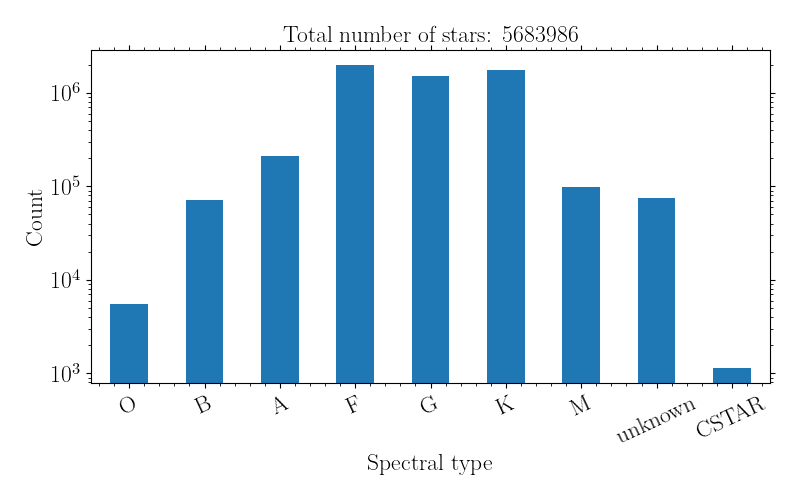

In [9]:
# Total number of stars after cuts
fig, ax = plt.subplots(1,1, figsize=(8,5))
order = ['O', 'B', 'A', 'F', 'G', 'K', 'M', 'unknown', 'CSTAR']
dt.spec.value_counts().loc[order].plot.bar(rot=25)
ax.set_title(f'Total number of stars: {dt.shape[0]}')
ax.set_xlabel('Spectral type')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


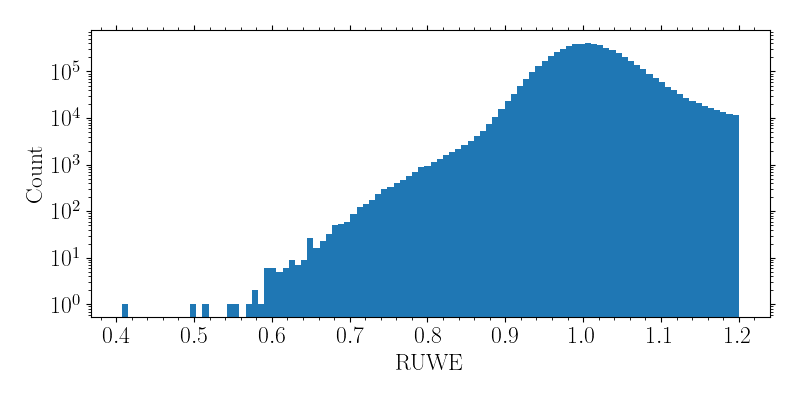

<IPython.core.display.Javascript object>


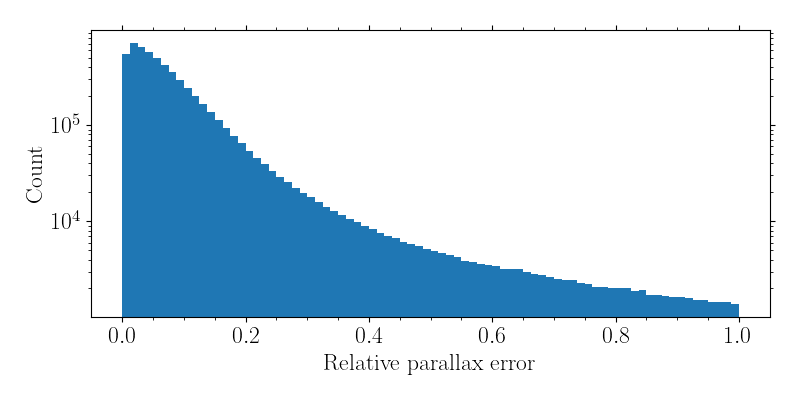

<IPython.core.display.Javascript object>


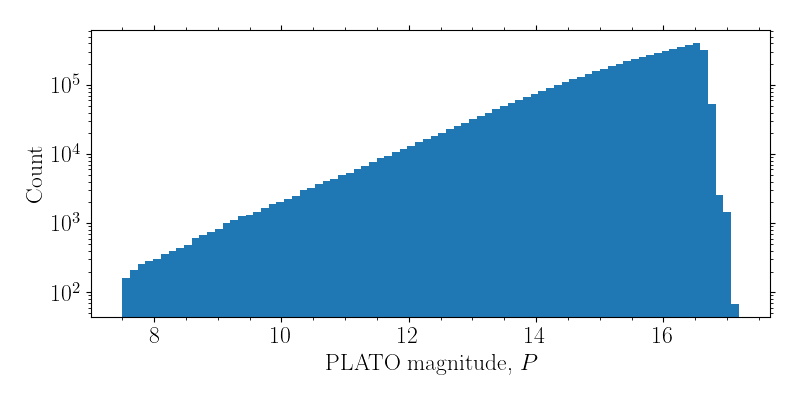

In [10]:
# Inspect uncertainties
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(dt.ruwe, bins=100)
ax.set_xlabel('RUWE')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

# Inspect parallax uncertainties
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(dt.plx_err/dt.plx, bins=80)
ax.set_xlabel('Relative parallax error')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

# Inspect P magnitudes
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(dt.Pmag, bins=80)
ax.set_xlabel(r'PLATO magnitude, $P$')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### Define stellar samples from CaMD

In [11]:
dt

,starID,gaiaDR3,ra,dec,Gmag,BP_RP,Ag,plx,plx_err,pmra,...,spec,evol,variable,class,Pmag,PBmag,PRmag,ncams,d,Mg
0,775075,5327903980056142592,132.341180,-50.307509,7.816724,1.186265,0.1784,3.331585,0.016675,3.848236,...,K,657,NOT_AVAILABLE,,7.501071,7.877909,7.121664,6,300.157447,0.251578
1,46937,4654769251998529792,71.659958,-71.106019,7.796673,1.067525,0.1909,7.141039,0.015750,22.940891,...,K,510,NOT_AVAILABLE,,7.502044,7.827568,7.159562,6,140.035645,1.874580
2,3205328,5612628838262556160,110.928741,-28.411177,7.664896,0.501390,0.1341,3.480025,0.017652,-4.486496,...,F,360,NOT_AVAILABLE,,7.502477,7.629595,7.341204,6,287.354281,0.238708
3,4494911,5611245377753103360,106.419605,-26.047542,7.885908,1.609408,0.4594,1.172664,0.018742,-6.442346,...,K,581,NOT_AVAILABLE,,7.502974,8.102326,7.006111,6,852.759507,-2.227625
4,4152238,5588012697057764096,114.694707,-35.802884,7.825538,1.169446,0.0689,3.443181,0.018523,-0.961238,...,K,517,NOT_AVAILABLE,,7.512734,7.882077,7.138522,6,290.429122,0.441437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5683981,1960332,5550395719909084800,96.077941,-49.210941,16.967607,-0.083960,0.0180,0.130416,0.046688,0.176025,...,B,<NA>,NOT_AVAILABLE,,16.998373,16.979988,17.025024,24,7667.754230,2.526267
5683982,418447,5504835634546628608,104.706703,-51.435598,16.863514,-0.389694,0.0016,0.225629,0.051674,-4.361647,...,O,<NA>,NOT_AVAILABLE,,17.010639,16.930511,17.134272,24,4432.059500,3.628886
5683983,3308681,5551566669729955968,100.604233,-48.443102,16.896631,-0.308811,0.0085,0.223015,0.048652,-1.206527,...,B,<NA>,NOT_AVAILABLE,,17.012270,16.948116,17.110544,24,4484.008734,3.629799
5683984,2195720,5501837854749153024,101.431944,-51.680234,16.875198,-0.422529,0.0041,0.398762,0.047215,4.894729,...,O,<NA>,NOT_AVAILABLE,,17.035187,16.948614,17.169052,24,2507.760650,4.874668


In [12]:
# New regions to query from
gdor   = [(0.6, 2.2), 0.8, 2.0, -5]
dsct   = [(0.4, 1.6), 0.9, 2.3, -2]
rrlyr  = [(1.0,  1.3), 0.9, 3.0, -20]
ceph   = [(2.0, -2.5), 2.8, 7, -10]

# Seperate each class
dt_gdor   = mk.CaMD_ellipse(dt, gdor)
dt_dsct   = mk.CaMD_ellipse(dt, dsct)
dt_rrlyr  = mk.CaMD_ellipse(dt, rrlyr)
dt_ceph   = mk.CaMD_ellipse(dt, ceph)

# Connection points of kinks for dwarf/giant and dwrf/compact
xlim0 = 0.8
xlim1 = 0.3

# Connection line between two kinks (for SPB and beta Cep)
x2 = np.linspace(0.3, 0.8, 100)

# Fecth giants
req_giants = ((dt.BP_RP > xlim0) & (dt.Mg < mk.RG_upper(dt.BP_RP))) 
dt_giants = dt[req_giants]

# Fetch intermediate to massive stars (IMS: SPB and beta Cep)
req_IMS = ((dt.BP_RP < xlim1) & (dt.Mg < mk.WD_upper(dt.BP_RP)) |
           (dt.BP_RP > xlim1) & (dt.BP_RP < xlim0) & (dt.Mg < mk.IMS_line(dt.BP_RP))) 
dt_IMS = dt[req_IMS]

# Fetch sdBV
req_sdb = ((dt.BP_RP < xlim1) & (dt.Mg > mk.WD_upper(dt.BP_RP)) | 
           (dt.BP_RP > xlim1) & (dt.Mg > mk.WD_lower(dt.BP_RP)))
dt_sdb = dt[req_sdb]
dt_sdb = dt_sdb[(dt_sdb.Mg < 6)] # & (dt_sdb.ruwe > 1.2) & (dt_sdb.plx > 0.5)]m

# Fetch WDs
req_wd = ((df.BP_RP < xlim1) & (df.Mg > mk.WD_upper(df.BP_RP)) | 
          (df.BP_RP > xlim1) & (df.Mg > mk.WD_lower(df.BP_RP)))
dt_wd = df[req_wd]
dt_wd = dt_wd[(df.Mg > 7) & (dt_wd.ruwe < 1.2) & (dt_wd.plx > 2)] # plx=2 is 500pc

<IPython.core.display.Javascript object>


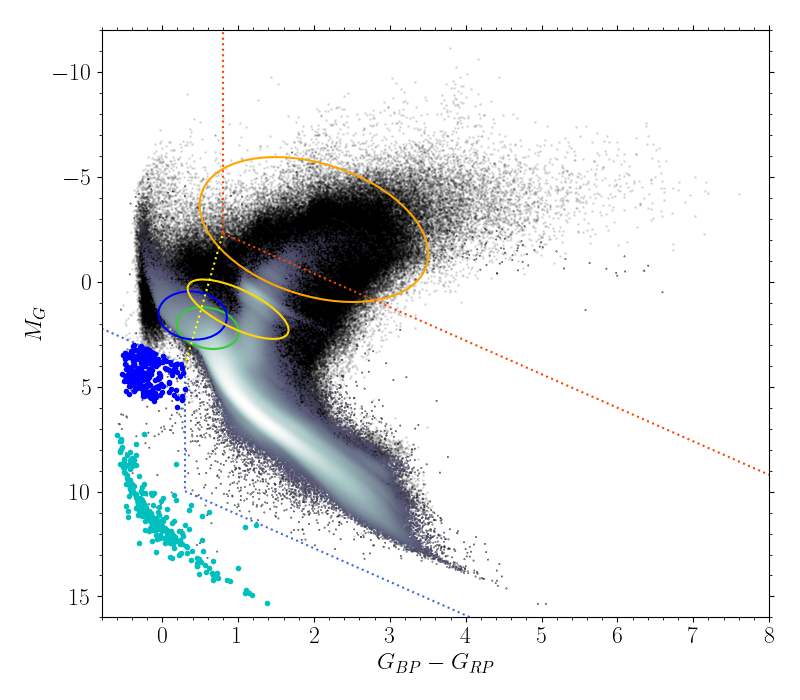

In [13]:
# CaMD OF STARS WITHIN 1 KPC
fig, ax = plt.subplots(1,1, figsize=(8,7))

# Plot ellipses of instability
ax.scatter(dt.BP_RP, dt.Mg, s=1, color='k', alpha=0.1, label='All stars')
ax.scatter(dx.x, dx.y, c=np.log10(dx.z), s=0.1, cmap="bone")

# Plot ellipses of instability
ellipse_gdor   = patches.Ellipse(gdor[0],   gdor[1],   gdor[2],   angle=gdor[3],   fill=False, lw=1.5, ec='limegreen')
ellipse_dsct   = patches.Ellipse(dsct[0],   dsct[1],   dsct[2],   angle=dsct[3],   fill=False, lw=1.5, ec='blue')
ellipse_rrly   = patches.Ellipse(rrlyr[0],  rrlyr[1],  rrlyr[2],  angle=rrlyr[3],  fill=False, lw=1.5, ec='gold')
ellipse_ceph   = patches.Ellipse(ceph[0],   ceph[1],   ceph[2],   angle=ceph[3],   fill=False, lw=1.5, ec='orange')
ax.add_patch(ellipse_gdor)
ax.add_patch(ellipse_dsct)
ax.add_patch(ellipse_rrly)
ax.add_patch(ellipse_ceph)

# Plot dwarf-giant division
xx = np.linspace(0.8, 8, 100)
ax.plot(xx, mk.RG_upper(xx), ':', c='orangered')
ax.plot([0.8, 0.8], [mk.RG_upper(xx)[0], -20], ':', c='orangered')

# Plot compact-objects division
xx_upper = np.linspace(-1, 0.3, 100)
xx_lower = np.linspace(0.3, 10, 100)
ax.plot(xx_upper, mk.WD_upper(xx_upper), ':', c='royalblue')
ax.plot([0.3, 0.3], [mk.WD_upper(xx_upper)[-1], 10], ':', c='royalblue')
ax.plot(xx_lower, mk.WD_lower(xx_lower), ':', c='royalblue')

# Plot sdBV and WD
ax.plot(dt_sdb.BP_RP, dt_sdb.Mg, 'b.')
ax.plot(dt_wd.BP_RP, dt_wd.Mg, 'c.')

# Plot interconnection
ax.plot(x2, mk.IMS_line(x2), ':', c='yellow')

# Settings
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
ax.set_xlim(-0.8, 8)
ax.set_ylim(16, -12)
plt.tight_layout();

## Main-sequence pulsators

### *$\gamma$ Doradus*

In [ ]:
nstars = 1000

# All stars
ds = dt_gdor
n_all = [ds[ds.ncams == i].shape[0] for i in [6,12,18,24]]
print('Before cuts:', n_all)

# Perform cuts
ds = ds[(ds.Pmag <= 14) &
        (ds.M > 1.2) & (ds.M < 2.0) & 
        (ds.Teff > 6500) & (ds.Teff < 9000) & 
        (ds.logg > 3.5) & (ds.L > 2.0)]
n_cat = [ds[ds.ncams == i].shape[0] for i in [6,12,18,24]]
print('After cuts :', n_cat)

# Fetch sample
ds = mk.fetch_sample(ds, nstars, seed=seed, max_mag=13, max_weight=0.02)
ds_gdor = ds

In [ ]:
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=ds.ra, decStars=ds.dec, c=ds.Pmag, ncamStars=True,
                          clabel=r'$\mathcal{P}$ [mag]', figsize=(9,9))
fig.savefig(f'{fdir}/starcat_sky_GDOR.png', bbox_inches='tight', dpi=200)

In [ ]:
fig, ax = pt.plotHistogramSED(ds)
fig.savefig(f'{fdir}/starcat_hist_GDOR.png', bbox_inches='tight', dpi=200)

In [ ]:
# PLOT THE MAIN TARGET HRD
fig, ax = plt.subplots(1,1, figsize=(7, 6.5))

# Plot stars
ds = ds.sort_values('logg', ascending=False)
mk.plot_HRD(fig, ax, ds.Teff, np.log10(ds.L), c=ds.logg, clab=r'log $g$', anchor=(0.05, 0.15, 1, 1))

# Plot stellar evolutionary tracks
Mini = ['00120', '00130', '00140', '00150', '00160', '00170', '00180', '00190', '00200', '00210']
labs = ['00120', '00200', '00210']
mk.mist_tracks(path, ax, Mini, Agei=230, Agee=600, xoff=0.01, yoff=-0.05, labels_off=labs, plot=True)
    
# Plot instability strips
mk.plot_IS_gDor(ax, alpha=2.0, ls='-',  c='orangered')
mk.plot_IS_gDor(ax, alpha=1.5, ls='--', c='orangered')
mk.plot_IS_dSct(ax, ls='--', c='orange')

# Settings
ax.set_xlim(9500, 6400)
ax.set_ylim(0.3, 1.4)
plt.tight_layout()

# Save figure
fig.savefig(f'{fdir}/starcat_HRD_GDOR.png', bbox_inches='tight', dpi=200)

In [ ]:
# Create target catalogue
ds.reset_index(drop=True, inplace=True)
ds.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_gDor_targets.ftr')

In [ ]:
# Create contaminant catalogue
dc = ut.getContaminants(ds, df, column='gaiaDR3')
dc.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_gDor_contaminants.ftr')

### *SPB stars*

In [ ]:
nstars = 1000

# Select stars
ds = dt_IMS
n_all = [ds[ds.ncams == i].shape[0] for i in [6,12,18,24]]
print('Before cuts :', n_all)

# Stars after cuts
da = ds[(ds.spec == 'A')]
ds = ds[(ds.spec == 'B')]

# Remove stars from LMC
lmc = [79.8917, -68.7511]
ds['dis'] = ut.radialDistance(lmc[0], lmc[1], ds.ra, ds.dec)
ds = ds[(ds.dis > 6) | (ds.Pmag < 10)]
ds = ds[(ds.Pmag < 16)]
da = da[(da.Pmag < 16)]

# Remaining stars
n_cat = [ds[ds.ncams == i].shape[0] for i in [6,12,18,24]]
print('After cuts  :', n_cat)

# Fetch all possible B stars
ds = mk.fetch_sample(ds, nstars, seed=seed)

In [ ]:
# Number of missing stars
n18, n24 = nstars - np.array([ds[ds.ncams == i].shape[0] for i in [18,24]])

# Use A type stars to fill in
da18 = da[da.ncams == 18]
da24 = da[da.ncams == 24]
da = pd.concat([ds[ds.ncams==6], ds[ds.ncams==12], da18, da24])

# Fetch missing stars again from weighted distribution
da = mk.fetch_sample(da, nstars=[nstars, nstars, n18, n24], max_mag=12, max_weight=0.01)

# Combine B and A stars
ds = pd.concat([ds, da[da.ncams==18], da[da.ncams==24]])
print('All stars after cuts :', [ds[ds.ncams == i].shape[0] for i in [6,12,18,24]])

In [ ]:
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=ds.ra, decStars=ds.dec, c=ds.Pmag, ncamStars=True, 
                          clabel=r'$P$ [mag]', figsize=(9,9))
fig.savefig(f'{fdir}/starcat_sky_SPB.png', bbox_inches='tight', dpi=200)

In [ ]:
# # Total number of stars after cuts
# fig, ax = plt.subplots(1,1, figsize=(8,5))
# order = ds.spec.unique()
# ds.spec.value_counts().loc[order].plot.bar(rot=25)
# ax.set_title(f'Total number of stars: {ds.shape[0]}')
# ax.set_xlabel('Spectral type')
# ax.set_ylabel('Count')
# plt.tight_layout()
# plt.show()

In [ ]:
# SAMPLE STELLAR PARAMETERS
# Since Gaia do not have any paramter estimation for massive (>8Msun) stars
# we construct a HRD polygon spanning the mass range of beta Cepheids and 
# that only contains stars from the ZAMS to teh TAMS.

# Bounds defined by IS
Teff_IS_low, Teff_IS_upp, logL_IS_low, logL_IS_upp = mk.IS_OB(path, modes='g', rot_roche=0)

# Bound defined by the ZAMS
Teff_zams = Teff_IS_low[:6].to_numpy().tolist()
logL_zams = logL_IS_low[:6].to_numpy().tolist()

# Bound before the TAMS
Teff_tams = [8240] + Teff_IS_upp[1:6].to_numpy().tolist()
logL_tams = [1.846] + logL_IS_upp[1:6].to_numpy().tolist()

# Lower mass limit
f = f'{path}/tracks/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.0_EEPS/00250M.track.eep'
s = np.loadtxt(f, skiprows=12, usecols=[0, 1, 11, 6])
age, mass, logT, logL = s[:,0], s[:,1], s[:,2], s[:,3]
zams, agee = 270, 400
Teff_mass_low = 10**logT[zams:agee]
logL_mass_low = logL[zams:agee]

# Combine to a polygon
Teff_polygon = np.concatenate((Teff_zams, Teff_tams[::-1], Teff_mass_low[::-1]))
logL_polygon = np.concatenate((logL_zams, logL_tams[::-1], logL_mass_low[::-1]))
polygon = Polygon([[Teff_polygon[i], logL_polygon[i]] for i in range(len(Teff_polygon))])

# Fetch stars within polygon
xp, yp = polygon.exterior.xy
points = mk.Random_Points_in_Polygon(polygon, 4000)
ds.Teff = [point.x for point in points]
ds.L    = 10**np.array([point.y for point in points])

# Stellar mass
ds.M = 1/1.4 * ds.L**(2/7)
        
# Stellar radius
Teff_sun = 5777.
ds.R = ds.L**(1/2) * (ds.Teff/Teff_sun)**(-2)

# Surface gravity (scales with (M/M_sun)*(R/R_sun)**-2)
ds.logg = ds.M * ds.R**(-1.6) + 3.3

# We assume the metallicity of the star drawn are appropiate
ds = mk.draw_normal_Z(ds, rng, sigma=0.5)

# Store for paper plot
ds_spb = ds

In [ ]:
fig, ax = pt.plotHistogramSED(ds);
fig.savefig(f'{fdir}/starcat_hist_SPB.png', bbox_inches='tight', dpi=200)

In [ ]:
# Plot sample HRD
fig, ax = plt.subplots(1,1, figsize=(7,6.5))

# Plot stars and colorbar
mk.plot_HRD(fig, ax, ds.Teff, np.log10(ds.L), c=ds.logg, 
            clab=r'log $g$', anchor=(0.05, 0.15, 1, 1))
#---------------------------------------------------------
# ax.plot(Teff_polygon, logL_polygon, 'g.')
# ax.plot(xp,yp)
#---------------------------------------------------------

# Plot mist tracks
Mini = ['00150', '00200', '00250', '00300', '00400', '00500', '00600', '00700', '00800', '00900'] 
labels = ['00150', '00900']
mk.mist_tracks(path, ax, Mini, Agee=600, xoff=0.015, yoff=-0.13, labels_off=labels, plot=True);
    
# Plot instability strips
mk.plot_IS_dSct(ax, c='orange')
mk.plot_IS_OB(path, ax, modes='g', c='b', ls='-')
mk.plot_IS_OB(path, ax, modes='g', c='b', ls='-', )
mk.plot_IS_OB(path, ax, modes='p', c='m')

# Settings
ax.set_xlim(24300, 8000)
ax.set_ylim(1.0, 4.0)
plt.tight_layout()

# Save figure
fig.savefig(f'{fdir}/starcat_HRD_SPB.png', bbox_inches='tight', dpi=200)

In [ ]:
# Create target catalogue
ds.reset_index(drop=True, inplace=True)
ds.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_SPB_targets.ftr')

In [ ]:
# Create contaminant catalogue
dc = ut.getContaminants(ds, df, column='gaiaDR3')
dc.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_SPB_contaminants.ftr')

### *$\delta$ Scuti*

In [ ]:
nstars = 1000

# Select stars
ds = dt_dsct
n_all = [ds[ds.ncams == i].shape[0] for i in [6,12,18,24]]
print('Before cuts :', n_all)

# Perform cuts and select stars within the dSct observational boundaries
poly_low = np.polyfit([7300, 6500], [0.7, 1.4], deg=1)
poly_upp = np.polyfit([9300, 8500], [1.18, 2.05], deg=1)
xx = np.arange(6000, 10000)
L_low = np.polyval(poly_low, xx)
L_upp = np.polyval(poly_upp, xx)
ds = ds[(np.log10(ds.L) > np.polyval(poly_low, ds.Teff)) & 
        (np.log10(ds.L) < np.polyval(poly_upp, ds.Teff)) &
        (ds.M > 1.5) & (ds.M < 2.5) & 
        (ds.logg > 3.5) & 
        (ds.L > 2)]
    
# Show counts per camera group
n_cat = [ds[ds.ncams == i].shape[0] for i in [6,12,18,24]]
print('After cuts  :', n_cat)

# Fetch sample
ds = mk.fetch_sample(ds, nstars, seed=seed, max_mag=13, max_weight=0.02)
ds = mk.draw_normal_Z(ds, rng)
ds_dsct = ds

In [ ]:
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=ds.ra, decStars=ds.dec, c=ds.Pmag, ncamStars=True,
                          clabel=r'$\mathcal{P}$ [mag]', figsize=(9,9))
fig.savefig(f'{fdir}/starcat_sky_DSCT.png', bbox_inches='tight', dpi=200)

In [ ]:
fig, ax = pt.plotHistogramSED(ds);
fig.savefig(f'{fdir}/starcat_hist_DSCT.png', bbox_inches='tight', dpi=200)

In [ ]:
# PLOT THE MAIN TARGET HRD
fig, ax = plt.subplots(1, 1, figsize=(7, 6.5))

# Plot stars
mk.plot_HRD(fig, ax, ds.Teff, np.log10(ds.L), c=ds.logg, clab=r'log $g$', anchor=(0.00, 0.10, 1, 1))

# Plot stellar evolutionary tracks
Mini = ['00140', '00150', '00160', '00170', '00180', '00190', '00200', '00210', '00220', '00230', '00240']  
labels = ['00140', '00200', '00210', '00220', '00230', '00240']
mk.mist_tracks(path, ax, Mini, Agei=230, Agee=600, xoff=0.009, yoff=-0.05, labels_off=labels, plot=True);

# Plot instability strips
mk.plot_IS_gDor(ax, c='orangered')
mk.plot_IS_dSct(ax, c='orange', ls='-')

# Settings
ax.set_xlim(9500, 6500)
ax.set_ylim(0.6, 1.8)
plt.tight_layout()

# Save figure
fig.savefig(f'{fdir}/starcat_HRD_DSCT.png', bbox_inches='tight', dpi=200)

In [ ]:
# Create target catalogue
ds.reset_index(drop=True, inplace=True)
ds.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_dSct_targets.ftr')

In [ ]:
# Create contaminant catalogue
dc = ut.getContaminants(ds, df, column='gaiaDR3')
dc.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_dSct_contaminants.ftr')

### *$\beta$ Cephei stars*

In [ ]:
# Select stars
nstars = 500
ds = dt_IMS
n_all = [ds[ds.ncams == i].shape[0] for i in [6,12,18,24]]
print('Before cuts :', n_all)

# Stars after cuts
da = ds[(ds.spec == 'A')]
ds_O = ds[(ds.spec == 'O')]
ds_B = ds[(ds.spec == 'B')]
ds = pd.concat([ds_O, ds_B])

# Remove stars from LMC
lmc = [79.8917, -68.7511]
ds['dis'] = ut.radialDistance(lmc[0], lmc[1], ds.ra, ds.dec)
ds = ds[(ds.dis > 6) | (ds.Pmag < 10)]

n_all = [ds[ds.ncams == i].shape[0] for i in [6,12,18,24]]
print('After cuts  :', n_all)

# Fetch stars
ds = mk.fetch_sample(ds, nstars)

In [ ]:
# Number of missing stars
n18, n24 = nstars - np.array([ds[ds.ncams == i].shape[0] for i in [18,24]])

# Use A type stars to fill in
da18 = da[da.ncams == 18]
da24 = da[da.ncams == 24]
da = pd.concat([ds[ds.ncams==6], ds[ds.ncams==12], da18, da24])

# Fetch missing stars again from weighted distribution
da = mk.fetch_sample(da, nstars=[nstars, nstars, n18, n24], seed=seed, max_mag=12, max_weight=0.03)

# Combine OB with A stars
ds = pd.concat([ds, da[da.ncams==18], da[da.ncams==24]])
print('All stars after cuts :', [ds[ds.ncams == i].shape[0] for i in [6,12,18,24]])

In [ ]:
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=ds.ra, decStars=ds.dec, c=ds.Pmag, ncamStars=True,
                          clabel=r'$P$ [mag]', figsize=(9,9))
fig.savefig(f'{fdir}/starcat_sky_BCEP.png', bbox_inches='tight', dpi=200)

In [ ]:
# SAMPLE STELLAR PARAMETERS:
# Since Gaia do not have any paramter estimation for massive (>8Msun) stars
# we construct a HRD polygon spanning the mass range of beta Cepheids and 
# that only contains stars from the ZAMS to teh TAMS.
n = ds.shape[0]
Teff_IS_low, Teff_IS_upp, logL_IS_low, logL_IS_upp = mk.IS_OB(path, modes='p', rot_roche=0)

# Bound defined by the ZAMS
Teff_zams = Teff_IS_low[:6].to_numpy().tolist()
logL_zams = logL_IS_low[:6].to_numpy().tolist()

# Bound before the TAMS
Teff_tams = Teff_IS_upp[:6].to_numpy().tolist()
logL_tams = logL_IS_upp[:6].to_numpy().tolist()

# Combine to a polygon
Teff_polygon = np.concatenate((Teff_zams, Teff_tams[::-1])) 
logL_polygon = np.concatenate((logL_zams, logL_tams[::-1]))
polygon = Polygon([[Teff_polygon[i], logL_polygon[i]] for i in range(len(Teff_polygon))])

# Fetch stars within polygon
xp, yp = polygon.exterior.xy
points = mk.Random_Points_in_Polygon(polygon, int(4*nstars))
ds.Teff = [point.x for point in points]
ds.L    = 10**np.array([point.y for point in points])

# Stellar mass
ds.M = 1/1.4 * ds.L**(2.09/7)
        
# Stellar radius
Teff_sun = 5777.
ds.R = ds.L**(1/2) * (ds.Teff/Teff_sun)**(-2)

# Surface gravity (scales with (M/M_sun)*(R/R_sun)**-2)
ds.logg = ds.M * ds.R**(-1.6) + 3.3

# We assume the metallicity of the star drawn are appropiate
ds = mk.draw_normal_Z(ds, rng, sigma=0.5)
ds_bcep = ds

In [ ]:
fig, ax = pt.plotHistogramSED(ds);
fig.savefig(f'{fdir}/starcat_hist_BCEP.png', bbox_inches='tight', dpi=200)

In [ ]:
# Plot sample HRD
fig, ax = plt.subplots(1,1, figsize=(7,6.5))

# Plot stars and colorbar
mk.plot_HRD(fig, ax, ds.Teff, np.log10(ds.L), c=ds.logg, 
            clab=r'log $g$', anchor=(0.02, 0.12, 1, 1))
#---------------------------------------------------------
# ax.plot(Teff_polygon, logL_polygon, 'g.')
# ax.plot(xp,yp)
#---------------------------------------------------------

# Plot tracks etc
Mini = ['00600', '00800', '01000', '01300', '01600', '02000', '02600', '03400']
labs = ['00600', '03400']
mk.mist_tracks(path, ax, Mini, Agee=600, xoff=0.010, yoff=-0.09, labels_off=labs, plot=True);

# Plot instability strips
mk.plot_IS_OB(path, ax, modes='g', c='b', ls='--')
mk.plot_IS_OB(path, ax, modes='p', c='m', ls='-')

# Settings
ax.set_xlim(40500, 17800)
ax.set_ylim(3.3, 5.4)
plt.tight_layout();

# Save figure
fig.savefig(f'{fdir}/starcat_HRD_BCEP.png', bbox_inches='tight', dpi=200)

In [ ]:
# Create target catalogue
ds.reset_index(drop=True, inplace=True)
ds.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_bCep_targets.ftr')

In [ ]:
# Create contaminant catalogue
dc = ut.getContaminants(ds, df, column='gaiaDR3')
dc.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_bCep_contaminants.ftr')

#### Plots for paper

In [ ]:
# Plot sample HRD
fig, ax = plt.subplots(1,1, figsize=(7.5,6))

# Plot stars and colorbar
ds = pd.concat([ds_gdor, ds_spb])
mk.plot_HRD(fig, ax, np.log10(ds.Teff), np.log10(ds.L), c=ds.logg, log=True, 
            clab=r'log $g$', width="50%", height="4%", anchor=(0.05, 0.15, 1, 1), 
            vmin=3.6, vmax=4.4, ticks=[4.4, 4.2, 4.0, 3.9, 3.6])

# Plot tracks etc
Mini = ['00100', '00120', '00140', '00160', '00200', '00250', '00300', 
        '00400', '00500', '00600', '00800', '01100', '01700', '02600', '05000']
labs = ['00100', '05000']
mk.mist_tracks_modes(path, ax, Mini, Agei=202, Agee=600, xoff=0.05, yoff=-0.30, 
                  labels_off=labs, box_off=True, log=True, plot=True);

# Plot instability strips
mk.plot_IS_gDor(ax, alpha=2.0, ls='-',  c='orangered', log=True)
mk.plot_IS_gDor(ax, alpha=1.5, ls='--', c='orangered', log=True)
mk.plot_IS_dSct(ax, ls='--', c='orange', log=True)
mk.plot_IS_OB(path, ax, modes='p', c='m', ls='--', log=True)
mk.plot_IS_OB(path, ax, modes='g', c='b', ls='-', log=True)

# Settings
ax.set_xlim(4.65, 3.78)
ax.set_ylim(0.0, 5.6)
plt.tight_layout()

# Save figure
fig.savefig(f'{fdir}/HRD_gmodes.png', bbox_inches='tight', dpi=200)

In [ ]:
# Plot sample HRD
fig, ax = plt.subplots(1,1, figsize=(7.5, 6))

# Plot stars and colorbar
ds = pd.concat([ds_dsct, ds_bcep])
mk.plot_HRD(fig, ax, np.log10(ds.Teff), np.log10(ds.L), c=ds.logg, log=True,
            clab=r'log $g$', width="50%", height="4%", anchor=(0.05, 0.15, 1, 1), 
            vmin=3.6, vmax=4.4, ticks=[4.4, 4.2, 4.0, 3.9, 3.6])

# Plot tracks etc
Mini = ['00100', '00120', '00140', '00160', '00200', '00250', '00300', 
        '00400', '00500', '00600', '00800', '01100', '01700', '02600', '05000']
labs = ['00100', '05000']
mk.mist_tracks_modes(path, ax, Mini, Agei=202, Agee=600, xoff=0.05, yoff=-0.30, 
                     labels_off=labs, box_off=True, log=True, plot=True);

# Plot instability strips
mk.plot_IS_gDor(ax, alpha=2.0, ls='--',  c='orangered', log=True)
mk.plot_IS_dSct(ax, ls='-', c='orange', log=True)
mk.plot_IS_OB(path, ax, modes='g', c='b', ls='--', log=True)
mk.plot_IS_OB(path, ax, modes='p', c='m', ls='-', log=True)

# Settings
ax.set_xlim(4.65, 3.78)
ax.set_ylim(0.0, 5.6)
plt.tight_layout()

# Save figure
fig.savefig(f'{fdir}/HRD_pmodes.png', bbox_inches='tight', dpi=200)

## Evolved pulsators

In [14]:
def plotHistogramSED(df, title=False, figsize=(8,15)):

    # Compute ranges
    P_min, P_max = df.Gmag.min(), df.Gmag.max()
    M_min, M_max = df.M.min(), df.M.max()
    R_min, R_max = df.R.min(), df.R.max()
    Teff_min, Teff_max = df.Teff.min(), df.Teff.max()
    logg_min, logg_max = df.logg.min(), df.logg.max()
    Z_min, Z_max = df.Z.min(), df.Z.max()

    lw = 1.1
    c = 'r'
    
    # Inspect magnitude counts
    fig, ax = plt.subplots(6, 1, figsize=figsize)

    N = 50
    ax[0].hist(df.Gmag, bins=N, range=(P_min, P_max), histtype='step', ec=c, lw=lw)
    ax[0].set_xlabel(r'PLATO magnitude, $\mathcal{P}$')
    if title: ax[0].set_title(title, fontsize=20, pad=10)
    
    ax[1].hist(df.M, bins=N, range=(M_min, M_max), histtype='step', ec=c, lw=lw)
    ax[1].set_xlabel(r'Mass, $M$ [$M_{\odot}$]')

    ax[2].hist(df.R, bins=N, range=(R_min, R_max), histtype='step', ec=c, lw=lw)
    ax[2].set_xlabel(r'Radius, $R$ [$R_{\odot}$]')

    ax[3].hist(df.Teff, bins=N, range=(Teff_min, Teff_max), histtype='step', ec=c, lw=lw)
    ax[3].set_xlabel(r'Effective temperature, $T_{\rm eff}$ [K]')

    ax[4].hist(df.logg, bins=N, range=(logg_min, logg_max), histtype='step', ec=c, lw=lw)
    ax[4].set_xlabel(r'Surface gravity, log $g$ [dex]')
    
    ax[5].hist(df.Z, bins=N, range=(Z_min, Z_max), histtype='step', label='6',  ec=c, lw=lw)
    ax[5].set_xlabel(r'Metallicity, $Z$ [dex]')

    for i in range(6):
        ax[i].set_ylabel('Count')
        ax[i].get_yaxis().set_label_coords(-0.07, 0.5)
    plt.tight_layout(pad=0.5)
    
    return fig, ax

### *RR Lyrae*

In [6]:
# Load RR Lyrae from files
vdir = '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim'
filename = f'{vdir}/gaia_IDs_rrlyr.ids'
ID  = np.loadtxt(filename, usecols=[2], dtype=np.int64)
ra  = np.loadtxt(filename, usecols=[3])
dec = np.loadtxt(filename, usecols=[4])
N   = len(ID)

# Query the stellar parameters from Gaia database
df0 = pd.DataFrame()
for i in tqdm(range(N), bar_format=ut.tqdmBar()):
    df1 = sq.gaiaIDQuery(ID[i], ra[i], dec[i], radius=0.01, ofile=False)
    df1 = df1[df1.gaiaDR3 == ID[i]]
    df0 = pd.concat([df0, df1])
df_rrlyr = df0

In [ ]:
fig, ax = plotHistogramSED(df_rrlyr, figsize=(8,15))
fig.savefig(f'{fdir}/varsource_hist_RRLYR.png', bbox_inches='tight', dpi=200)

In [ ]:
# from textwrap import dedent
# ofile = f'{vdir}/rrl_cep_gaia_IDs.txt'
# textfile = ''
# for i in range(len(ID)):
#     textfile += f'Gaia DR3 {ID[i]}\n'
# with open(ofile, "w") as ofile:
#     ofile.write(dedent(textfile).strip())

In [ ]:
# Fetch sample
ds = dt_rrlyr

# Type-ab(d)
N_rrab = 1500
nstars_rrab = 375
ds_rrab = ds[(ds.logg > 1.5) & (ds.logg < 3.0) &
             (ds.Teff < 8000)]

# Type-c
N_rrc = 500
nstars_rrc = 125
ds_rrc = ds[(ds.logg > 2.5) & (ds.logg < 4.0) &
           (ds.Teff < 8000)]

# Show how many stars in each sub-sample
print('RR ab :', [ds_rrab[ds_rrab.ncams == i].shape[0] for i in [6,12,18,24]])
print('RR c  :', [ds_rrc[ds_rrc.ncams == i].shape[0] for i in [6,12,18,24]])

# Fetch RRab sample
ds_rrab = mk.fetch_sample(ds_rrab, nstars_rrab, seed=seed, max_mag=10, max_weight=0.1)

# Fetch RRc sample
ds_rrc = mk.fetch_sample(ds_rrc, nstars_rrc, seed=seed, max_mag=10, max_weight=0.1)

In [ ]:
# SAMPLE STELLAR PARAMETERS

# Stellar mass (Netzel et al. 2023): [0.5, 0.9]
ds_rrab.M = rng.normal(0.7, 0.05, N_rrab)
ds_rrc.M  = rng.normal(0.7, 0.05, N_rrc)

# Stellar radius (Marconi et al. 2005)
ds_rrab.R = rng.normal(6.0, 0.8, N_rrab)  # [4, 8]
ds_rrc.R  = rng.normal(5.5, 0.8, N_rrc)   # [3.5, 7.5]

# Effective temperature (from Gaia DR3 parameters)
ds_rrab.Teff = rng.normal(6200, 500, N_rrab)
ds_rrc.Teff  = rng.normal(6200, 500, N_rrc)

# Surface gravity (Molnar et al. 2023)
ds_rrab.logg = rng.normal(2.25, 0.75, N_rrab)  # [1.5, 3.0]
ds_rrc.logg  = rng.normal(3.25, 0.75, N_rrc)   # [2.5, 4.0]

# Metallicity (Clementini et al. 2023)
ds_rrab.Z = rng.normal(-1.02, 0.4, N_rrab)
ds_rrc.Z  = rng.normal(-1.02, 0.4, N_rrc)

# Combine catalogue in order of simulations
ds = pd.concat([ds_rrab, ds_rrc])

In [ ]:
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=ds.ra, decStars=ds.dec, c=ds.Pmag, 
                          ncamStars=True, clabel=r'$P$ [mag]', s=50, figsize=(9,9))
fig.savefig(f'{fdir}/starcat_sky_RRLYR.png', bbox_inches='tight', dpi=200)

In [ ]:
fig, ax = pt.plotHistogramSED(ds);
fig.savefig(f'{fdir}/starcat_hist_RRLYR.png', bbox_inches='tight', dpi=200)

In [ ]:
# Create target catalogue
ds.reset_index(drop=True, inplace=True)
ds.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_RRLyr_targets.ftr')

In [ ]:
# Create contaminant catalogue
dc = ut.getContaminants(ds, df, column='gaiaDR3')
dc.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_RRLyr_contaminants.ftr')

### *Cepheids*

In [ ]:
# vdir = '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim'
# filename = f'{vdir}/gaia_IDs_ceph.ids'
# ID  = np.loadtxt(filename, usecols=[2], dtype=np.int64)
# ra  = np.loadtxt(filename, usecols=[3])
# dec = np.loadtxt(filename, usecols=[4])
# N   = len(ID)

# # Query the stellar parameters from Gaia database
# df0 = pd.DataFrame()
# for i in tqdm(range(N), bar_format=ut.tqdmBar()):
#     df1 = sq.gaiaIDQuery(ID[i], ra[i], dec[i], radius=0.01, ofile=False)
#     df1 = df1[df1.gaiaDR3 == ID[i]]
#     df0 = pd.concat([df0, df1])
# df_ceph = df0

# fig, ax = plotHistogramSED(df_ceph, figsize=(8,15))
# fig.savefig(f'{fdir}/varsource_hist_CEPH.png', bbox_inches='tight', dpi=200)

In [ ]:
# Star within CaMD region
ds = dt_ceph

# dcep
N_dcep = 1000
n_dcep = 250
ds_dcep = ds[(ds.Teff < 6300)
             & (ds.logg < 2.5) & (ds.logg > 0.0)
             & (ds.M > 4) & (ds.M < 9)
             & (ds.R > 20) & (ds.R < 200)
            ]

# acep
N_acep = 200
n_acep = 50
ds_acep = ds[(ds.Teff < 8400)
             & (ds.logg < 3.0) & (ds.logg > 0.3)
             & (ds.M > 1.3) & (ds.M > 2)
             & (ds.R > 20) & (ds.R < 200)
            ]

# t2cep
N_t2cep = 800
n_t2cep = 200
ds_t2cep = ds[(ds.Teff < 7500)
              & (ds.logg < 4.0) & (ds.logg > 1.0)
              & (ds.M > 0.5) & (ds.M < 3.7) # Upper limit should be 0.8 Msun but no targets available then
              & (ds.R > 20) & (ds.R < 200)
             ]

# Show number of stars available
print([ds_dcep[ds_dcep.ncams == i].shape[0] for i in [6,12,18,24]])
print([ds_acep[ds_acep.ncams == i].shape[0] for i in [6,12,18,24]])
print([ds_t2cep[ds_t2cep.ncams == i].shape[0] for i in [6,12,18,24]])

# Fetch sample
ds_dcep = mk.fetch_sample(ds_dcep, n_dcep, seed=seed, max_mag=12, max_weight=0.2)

# Fetch sample
ds_acep = mk.fetch_sample(ds_acep, n_acep, seed=seed, max_mag=12, max_weight=0.2)

# Fetch sample
ds_t2cep = mk.fetch_sample(ds_t2cep, n_t2cep, seed=seed, max_mag=12, max_weight=0.5)

In [ ]:
# SAMPLE STELLAR PARAMETERS

# Stellar mass
ds_dcep.M  = rng.normal(6.5, 1.0, N_dcep)     # (Aert et al. 2010): [4, 9]
ds_acep.M  = rng.normal(1.65, 0.35, N_acep)   # (Aerts et al. 2010): [1.3, 2.0]
ds_t2cep.M = rng.normal(0.65, 0.15, N_t2cep)  # (Bono et al. 2020): [0.5, 0.8]

# Stellar radius TODO: use period-radius relations
ds_dcep.R  = rng.normal(3, 0.5, N_dcep)
ds_acep.R  = rng.normal(5, 1, N_acep)
ds_t2cep.R = rng.normal(10, 1, N_t2cep)

# Effective temperature
ds_dcep.Teff  = rng.normal(5400, 450, N_dcep)  # (Espinoza-Arancibia et al. 2024): [4500, 6300] 
ds_acep.Teff  = rng.normal(7100, 650, N_acep)  # (Ripepi et al. 2024) [5800, 8400]
ds_t2cep.Teff = rng.normal(6350, 575, N_t2cep) # (Schmidt et al. 2011): [5200, 7500]

# Surface gravity
ds_dcep.logg  = rng.normal(1.25, 0.625, N_dcep)  # (Lemasle et al. 2020): [0, 2.5]
ds_acep.logg  = rng.normal(1.65, 0.675, N_acep)  # (Ripepi et al. 2024) [0.3, 3]
ds_t2cep.logg = rng.normal(2.5, 0.6, N_t2cep)    # (Schmidt et al. 2011): [1, 4]

# Metallicity (Ripepi et al. 2023; Fig. 16)
ds_dcep.Z  = rng.normal(0.05, 0.3, N_dcep)
ds_acep.Z  = rng.normal(0.05, 0.3, N_acep)
ds_t2cep.Z = rng.normal(0.05, 0.3, N_t2cep)

# Combine catalogue in order of simulations
ds = pd.concat([ds_dcep, ds_acep, ds_t2cep])

In [ ]:
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=ds.ra, decStars=ds.dec, c=ds.Pmag, ncamStars=True,
                          clabel=r'$P$ [mag]', s=50, figsize=(9,9))
fig.savefig(f'{fdir}/starcat_sky_CEPH.png', bbox_inches='tight', dpi=200)

In [ ]:
fig, ax = pt.plotHistogramSED(ds);
fig.savefig(f'{fdir}/starcat_hist_CEPH.png', bbox_inches='tight', dpi=200)

In [ ]:
# Create target catalogue
ds.reset_index(drop=True, inplace=True)
ds.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_Ceph_targets.ftr')

In [ ]:
# Create contaminant catalogue
dc = ut.getContaminants(ds, df, column='gaiaDR3')
dc.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_Ceph_contaminants.ftr')

## Compact pulsators

### *sdBV stars*

In [17]:
# Fetch sample
ds = dt_sdb
ds_v361hya  = ds
ds_v1093her = ds

# Number of stars
nstars = 20
N_v361hya  = ds.shape[0]
N_v1093her = ds.shape[0]

print([ds[ds.ncams == i].shape[0] for i in [6,12,18,24]])

[137, 86, 20, 25]


In [18]:
# SAMPLE STELLAR PARAMETERS:

# Stellar mass (Netzel et al. 2023): [0.5, 0.9]
ds_v361hya.M  = rng.normal(0.46, 0.01, N_v361hya)
ds_v1093her.M = rng.normal(0.46, 0.01, N_v1093her)

# Stellar radius
ds_v361hya.R  = rng.normal(0.01, 0.001, N_v361hya)
ds_v1093her.R = rng.normal(0.01, 0.001, N_v1093her)

# Effective temperature (from Gaia DR3 parameters)
ds_v361hya.Teff  = rng.normal(32000, 1600, N_v361hya)   # [28, 35] kK
ds_v1093her.Teff = rng.normal(27000, 1600, N_v1093her)  # [22, 30] kK

# Surface gravity (Uzundag et al. 2024 c.f. Fig. 4)
ds_v361hya.logg  = rng.normal(5.65, 0.40, N_v361hya)   # [5.00, 6.25]
ds_v1093her.logg = rng.normal(5.40, 0.40, N_v1093her)  # [4.75, 6.00]

# Metallicity (Clementini et al. 2023)
ds_v361hya.Z  = rng.normal(-1.02, 0.4, N_v361hya)
ds_v1093her.Z = rng.normal(-1.02, 0.4, N_v1093her)

# Combine catalogue in order of simulations
ds = pd.concat([ds_v361hya, ds_v1093her])

In [21]:
# fig, ax = pt.plotHistogramSED(ds);
# fig.savefig(f'{fdir}/starcat_hist_SDBV.png', bbox_inches='tight', dpi=200)

(536, 42)

<IPython.core.display.Javascript object>


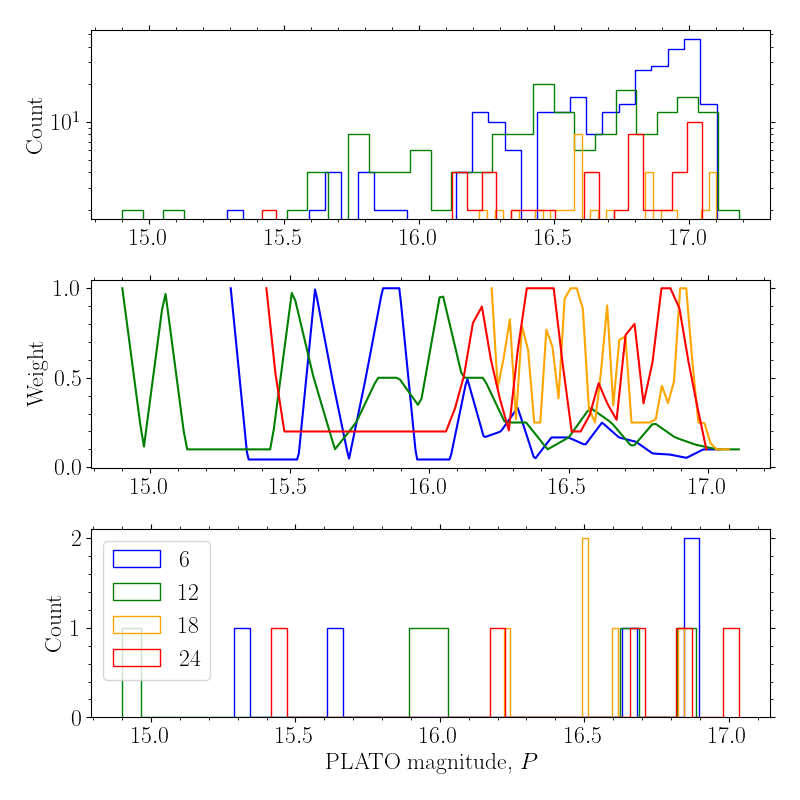

In [19]:
ds0 = mk.fetch_sample(ds, int(nstars/4), seed=1)

<IPython.core.display.Javascript object>


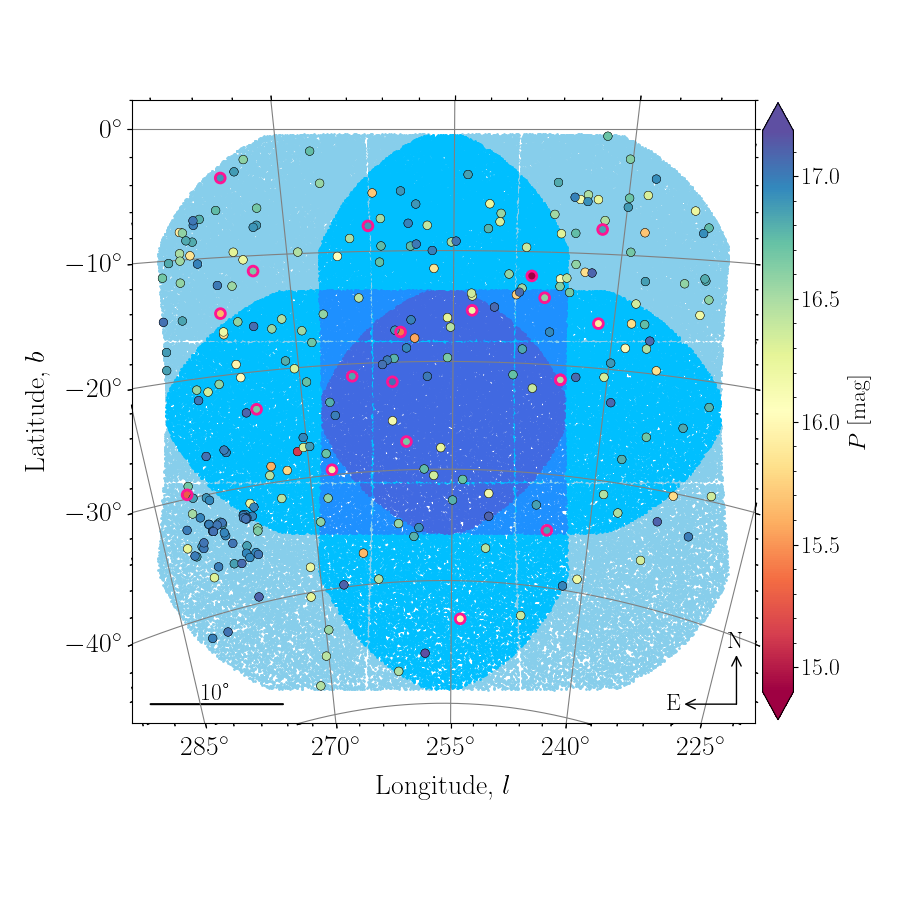

In [21]:
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=ds.ra, decStars=ds.dec, c=ds.Pmag, ncamStars=True,
                          clabel=r'$P$ [mag]', s=150, lw=0.3, figsize=(9,9))
cat = SkyCoord(ds0.ra, ds0.dec, frame='icrs', unit=u.deg)
ax.scatter(cat.ra.deg, cat.dec.deg, marker='o', ec='deeppink', fc='none', lw=2, 
           transform=ax.get_transform('icrs'), s=50, zorder=9);
fig.savefig(f'{fdir}/starcat_sky_SDBV.png', bbox_inches='tight', dpi=200)

In [39]:
# fig, ax = pt.plotPlatoFOV('LOPS2', raStars=ds.ra, decStars=ds.dec, c=ds.Pmag, ncamStars=True,
#                           clabel=r'$P$ [mag]', s=150, lw=0.3, figsize=(9,9))
# ID = 11
# dx = ds0.iloc[ID-1]
# cat = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg)
# ax.scatter(cat.ra.deg, cat.dec.deg, marker='o', ec='deeppink', fc='none', lw=2, 
#            transform=ax.get_transform('icrs'), s=50, zorder=9);

In [22]:
ds0

,starID,gaiaDR3,ra,dec,Gmag,BP_RP,Ag,plx,plx_err,pmra,...,spec,evol,variable,class,Pmag,PBmag,PRmag,ncams,d,Mg
0,1458793,5310683325886104576,138.946740,-54.272109,16.954941,0.161280,0.0002,0.491797,0.047674,0.578100,...,B,<NA>,NOT_AVAILABLE,,16.898741,16.935690,16.846876,6,2033.358829,5.413671
1,2932226,5277958148962865920,124.145309,-62.290004,15.543999,-0.221560,0.0009,0.496525,0.031886,-1.922219,...,O,<NA>,NOT_AVAILABLE,,15.626112,15.579461,15.696823,6,2013.997565,4.022804
2,100940,5278518036599685248,90.117200,-71.415833,15.149161,-0.371084,0.0000,0.469736,0.033803,1.882109,...,O,<NA>,NOT_AVAILABLE,,15.289015,15.212547,15.406830,6,2128.854882,3.508431
3,2635494,5606511670961134464,109.155535,-29.315255,16.938812,0.266209,0.0004,0.505565,0.049580,-1.103483,...,B,<NA>,VARIABLE,beStar,16.847969,16.910761,16.762299,6,1977.984435,5.457298
4,2442500,5314795087031449984,126.471918,-57.790740,16.558525,-0.267517,0.0534,0.489689,0.043639,-0.888759,...,O,<NA>,NOT_AVAILABLE,,16.658230,16.602318,16.743484,6,2042.114523,4.954725
5,470,5519245906965252608,122.141096,-47.325345,16.917656,0.084694,0.2379,0.411353,0.052885,-10.829549,...,B,<NA>,NOT_AVAILABLE,,16.887720,16.906742,16.860508,12,2431.004656,4.750827
6,1436819,5583804144499696256,100.359973,-32.229094,15.806387,-0.271664,0.0007,0.425952,0.034527,7.776909,...,B,<NA>,NOT_AVAILABLE,,15.907687,15.850945,15.994250,12,2347.683964,3.952489
7,4568121,5590188699286046720,107.707456,-36.365597,14.968379,0.195648,0.0002,0.619326,0.021108,5.049737,...,O,<NA>,NOT_AVAILABLE,,14.900658,14.945899,14.837721,12,1614.658410,3.927776
8,147188,5285464377404208128,104.866055,-63.953963,16.560242,-0.270887,0.0528,0.383279,0.042279,1.491303,...,O,<NA>,NOT_AVAILABLE,,16.661243,16.604656,16.747561,12,2609.068631,4.425014
9,349337,4789068103329323648,67.387075,-47.529026,15.788722,-0.496614,0.0018,0.334611,0.035793,7.012141,...,O,<NA>,NOT_AVAILABLE,,15.977830,15.876757,16.134645,12,2988.545235,3.409623


In [ ]:
# Create target catalogue
ds0.reset_index(drop=True, inplace=True)
ds0.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_sdBV_targets.ftr')

In [ ]:
# Create contaminant catalogue
dc = ut.getContaminants(ds0, df, column='gaiaDR3')
dc.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_sdBV_contaminants.ftr')

### *White dwarfs*

In [ ]:
# Fetch sample
nstars = 20
ds = dt_wd
ds = ds.sort_values(['ncams', 'Gmag'])
print(ds.shape[0], [ds[ds.ncams == i].shape[0] for i in [6,12,18,24]])

In [ ]:
# Fetch final sample
ds0 = mk.fetch_sample(ds, int(nstars/4), seed=1)

In [ ]:
# Plot stars in sky
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=ds.ra, decStars=ds.dec, c=ds.Pmag, 
                          ncamStars=True, clabel=r'$P$ [mag]', s=150, lw=0.3, figsize=(9,9))
cat = SkyCoord(ds0.ra, ds0.dec, frame='icrs', unit=u.deg)
ax.scatter(cat.ra.deg, cat.dec.deg, marker='o', ec='deeppink', fc='none', lw=2, 
           transform=ax.get_transform('icrs'), s=50, zorder=9);
fig.savefig(f'{fdir}/starcat_sky_WD.png', bbox_inches='tight', dpi=200)

In [ ]:
# Create target catalogue
ds0.reset_index(drop=True, inplace=True)
ds0.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_WD_targets.ftr')

In [ ]:
# Create contaminant catalogue
dc = ut.getContaminants(ds0, df, column='gaiaDR3')
dc.to_feather(f'{idir}/starcat_GaiaDR3_PlatoCS_WD_contaminants.ftr')

---
## Testing space
---

### *Samples from HRD*

In [ ]:
# Upper and lower errors
M_err_upp = (dt.M_upp - dt.M) / dt.M
M_err_low = (dt.M - dt.M_low) / dt.M

# Remove stars with large errors
dt = dt[M_err_upp < 0.5]
dt = dt[M_err_low < 0.5]

# Histogram of errors
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(M_err_upp*100, bins=100, label='Upper error')
ax.hist(M_err_low*100, bins=100, label='Lower error')
ax.set_xlabel(r'Mass error [\%]')
ax.set_ylabel('Count')
ax.set_yscale('log')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# Upper and lower errors
R_err_upp = (dt.R_upp - dt.R) / dt.R
R_err_low = (dt.R - dt.R_low) / dt.R

# Histogram of errors
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(R_err_upp, bins=100, label='Upper error')
ax.hist(R_err_low, bins=100, label='Lower error')
ax.set_xlabel(r'Radius error [\%]')
ax.set_ylabel('Count')
ax.set_yscale('log')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# Upper and lower errors
logg_err_upp = (dt.logg_upp - dt.logg) / dt.logg
logg_err_low = (dt.logg - dt.logg_low) / dt.logg

# Histogram of errors
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(logg_err_upp, bins=100, label='Upper error')
ax.hist(logg_err_low, bins=100, label='Lower error')
ax.set_xlabel(r'log $g$ error [\%]')
ax.set_ylabel('Count')
ax.set_yscale('log')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# Remove NaNs for targets (i.e. all stars have defined extinction, Ag)
dt0 = dt.dropna()

# PLOT THE MAIN TARGET HRD
fig, ax = plt.subplots(1,1, figsize=(7,9))

# Plot HRD and Sun
dt0 = dt.iloc[::5]
im = ax.scatter(np.log10(dt0.Teff), np.log10(dt0.L), c=dt0.logg, s=1, cmap="PuOr") # PRGn
# ax1 = ax.twiny()
# ax1.plot(ds.spec, ds.L, ',')

# Color bar
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins = inset_axes(ax, width="50%", height="3%", loc="lower left",
    bbox_to_anchor=(0.05, 0.083, 1, 1), bbox_transform=ax.transAxes)
cbar = fig.colorbar(im, cax=axins, extend='both', orientation='horizontal', 
                    ticks=[1, 2, 3, 4])
# cbar = fig.colorbar(im, extend='both', shrink=0.8, pad=0.015)
cbar.set_label(r"log $g$", labelpad=3)                                    
cbar.ax.tick_params()
cbar.ax.invert_xaxis()

# Plot stellar evolutionary tracks
plot_tracks(ax)
    
# Plot the Sun
ax.plot(np.log10(5777), np.log10(1), marker=r'$\odot$', c='lightyellow', ms=15)
    
# Settings
# ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
ax.set_xlabel(r'log $T_{\rm eff}$ [dex]')
ax.set_ylabel(r'log $L$ [dex]')
ax.invert_xaxis()
ax.set_xlim(4.4, 3.415)
ax.set_ylim(-1.5, 4.3)
plt.tight_layout()
plt.show();

# Save figure
# fig.savefig(f'{fdir}/HRD.png', bbox_inches='tight', dpi=200)

In [ ]:
df0 = dt
# Classic instability strip
def y1(x):
    return -20.00*x + 78.00 
def y2(x):
    return -20.00*x + 80.00 

# # Cool dwarf dominated by stellar activity
# df_spot = df0[(np.log10(df0.L) < -0.2) & 
#               (df0.logg > 4.0) &
#               (df0.M < 0.95)]

# # Solar-like and SG stars
# df_sol = df0[(np.log10(df0.Teff) > 3.6) & (np.log10(df0.Teff) < 3.9) &
#              (np.log10(df0.L) > -0.2)   & (np.log10(df0.L) < 0.9)    &
#              (df0.M > 0.80) & (df0.M < 1.5) &
#              (df0.logg > 4.2)]

# # Solar SG and RGB stars
# df_sgrg = df0[(np.log10(df0.Teff) < 3.8) & 
#               (np.log10(df0.L) > 0.3)    & (np.log10(df0.L) < 2.5) &
#               (df0.M > 0.8)              & (df0.M < 3.2) &
#               (df0.logg < 3.5)]

# # RR Lyrae
# df_rrl = df0[(np.log10(df0.Teff) > 3.7) & (np.log10(df0.Teff) < 4.0) &
#               (np.log10(df0.L) > 1.6)     & (np.log10(df0.L) < 1.9)   &
# #           (df0.M > 0.6)               & (df0.M < 0.8)               &
#               (np.log10(df0.L) > y1(np.log10(df0.Teff))) & (np.log10(df0.L) < y2(np.log10(df0.Teff)))]

# # Cepheids
# df_ceph = df0[(np.log10(df0.Teff) > 3.6) & (np.log10(df0.Teff) < 3.9) &
#               (np.log10(df0.L) > 1.9)    &
# #           (df0.M > 0.6)               & (df0.M < 0.8)               &
#               (np.log10(df0.L) > y1(np.log10(df0.Teff))) & (np.log10(df0.L) < y2(np.log10(df0.Teff)))]

# # Mira stars
# df_mira = df0[(np.log10(df0.Teff) < 3.75) & 
#               (np.log10(df0.L) > 2.3)     &
#               (df0.logg < 2.5)]

# delta Scuti
# df_dsct = df0[(np.log10(df_dsct.Teff) > 3.7) & (np.log10(df_dsct.Teff) < 4.0) &
#               (np.log10(df_dsct.L) > 0.8) & (np.log10(df_dsct.L) < 1.6) &
#               (df_dsct.M > 1.5) & (df_dsct.M < 2.5) &
#               (np.log10(df_dsct.L) > y1(np.log10(df0.Teff))) & (np.log10(df0.L) < y2(np.log10(df0.Teff)))
#              ]
# SPB stars
df_spbs = df_spbs[(np.log10(df_spbs.Teff) > 4.0) & (np.log10(df_spbs.Teff) < 4.35) &
                  (np.log10(df0.L) > 1.7) & (np.log10(df0.L) < 3.5) &
                  (df_spbs.M > 2.9) & (df_spbs.M < 9.0) &
                  (df_spbs.logg > 3.0)
                 ]

In [ ]:
# PLOT THE MAIN TARGET HRD
fig, ax = plt.subplots(1,1, figsize=(9,9))

# Plot HRD and Sun
df0 = dt.iloc[::1]
aa = 0.2
im0 = ax.scatter(np.log10(df0.Teff), np.log10(df0.L), c='darkblue', s=1, alpha=0.1, label='All stars')
im1 = ax.scatter(np.log10(df_spot.Teff), np.log10(df_spot.L), s=1, c='tomato', label='Cool dwarf')
im2 = ax.scatter(np.log10(df_sol.Teff),  np.log10(df_sol.L),  s=1, c='gold', alpha=aa, label='Solar-like')
im3 = ax.scatter(np.log10(df_sgrg.Teff), np.log10(df_sgrg.L), s=1, c='orange', alpha=aa, label='SG + RG')
im4 = ax.scatter(np.log10(df_mira.Teff), np.log10(df_mira.L), s=1, c='red', alpha=aa, label='Mira')
im5 = ax.scatter(np.log10(df_dsct.Teff), np.log10(df_dsct.L), s=1, c='forestgreen', alpha=aa, label='d Sct')
im6 = ax.scatter(np.log10(df_gdor.Teff), np.log10(df_gdor.L), s=1, c='lime', alpha=aa, label='g Dor')
im7 = ax.scatter(np.log10(df_rrl.Teff),  np.log10(df_rrl.L),  s=1, c='b', alpha=aa, label='RR Lyr')
im8 = ax.scatter(np.log10(df_ceph.Teff), np.log10(df_ceph.L), s=1, c='m', alpha=aa, label='Ceph')
im9 = ax.scatter(np.log10(df_spb.Teff),  np.log10(df_spb.L),  s=1, c='deeppink', alpha=aa, label='SPB')

# Classic instability strip
def y1(x):
    return -20.00*x + 78.00 
def y2(x):
    return -20.00*x + 80.00 
x1 = np.linspace(3.88, 3.6, 100)
x2 = np.linspace(3.97, 3.6, 100)
ax.plot(x1, y1(x1), '--', c='k')
ax.plot(x2, y2(x2), '--', c='k')

# Plot stellar evolutionary tracks
plot_tracks(ax)
    
# Plot the Sun
ax.plot(np.log10(5777), np.log10(1), marker=r'$\odot$', c='lightyellow', ms=15)

# Settings
ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
ax.set_xlabel(r'log $T_{\rm eff}$ [dex]')
ax.set_ylabel(r'log $L$ [dex]')
ax.invert_xaxis()
legend = ax.legend(handles=[im0, im1, im2, im3, im4, im5, im6, im7, im8, im9], loc='lower left')
# for legend_handle in legend.legendHandles:
#     legend_handle._legmarker.set_markersize(9)

# leg.legendHandles[0]._legmarker.set_markersize(6)

ax.set_xlim(4.35, 3.42)
ax.set_ylim(-1.7, 4.25)
plt.tight_layout()
plt.show();

# Save figure
# plt.savefig(f'{fdir}/HRD.png', bbox_inches='tight', dpi=200)

In [ ]:
# dc0 = pd.read_feather(idir /  'starcat_GaiaDR3_PlatoCS.ftr')
# dt0 = pd.read_feather(idir / f'starcat_GaiaDR3_PlatoCS_{starType}_targets.ftr')

In [ ]:
# Log axes
# ax.set_xlabel(r'$T_{\rm eff}$ [K]')
# ax.set_ylabel(r'$L$ [$L_{\odot}$]')
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.invert_xaxis()
# # We change the fontsize of major and minor ticks label 
# ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.16g}'.format(y)))
# ticks_major = [20000, 10000]
# ax.xaxis.set_major_locator(mticker.FixedLocator(ticks_major))
# ax.set_xticklabels(ticks_major)
# ax.xaxis.set_minor_formatter(FuncFormatter(lambda x, _: '{:.16g}'.format(x)))
# ticks_minor = [14000, 7000, 5000, 3800]
# ax.xaxis.set_minor_locator(mticker.FixedLocator(ticks_minor))
# ticks_major = [4.5, 4.0, 3.5]
# ax.xaxis.set_major_locator(mticker.FixedLocator(ticks_major))
# ax.set_xticklabels(ticks_major)
# ax.xaxis.set_minor_formatter(FuncFormatter(lambda x, _: '{:.16g}'.format(x)))
# ticks_minor = [4.4, 4.3, 4.2, 4.1, 3.9, 3.8, 3.7, 3.6]
# ax.xaxis.set_minor_locator(mticker.FixedLocator(ticks_minor))

In [ ]:
spectype = np.array(['O', 'B', 'A', 'F', 'G', 'K', 'M', 'unknown'])
spectype = spectype.reshape(2,4)
spectype[1][1]

In [ ]:
x = 45/3600.
dc_i = df[(df.ra  > df_i.ra.to_numpy()[0]  - x) & (df.ra  < df_i.ra.to_numpy()[0]  + x) &
          (df.dec > df_i.dec.to_numpy()[0] - x) & (df.dec < df_i.dec.to_numpy()[0] + x)]

In [ ]:
# Remove stars without color information
# dt = dt.drop(dt[dt.BP_RP == 0].index)
df_i

In [ ]:
# Division between dwarfs and subginats/giants
ds = df[df.R < ut.getMainSequenceLimit(df.Teff)]
sg = df[df.R > ut.getMainSequenceLimit(df.Teff)]

In [ ]:
# ms, aa = 2, 1
# spectype = np.array(['O', 'B', 'A', 'F', 'G', 'K', 'M', 'unknown', 'CSTAR'])

# plt.figure(figsize=(8,6))
# for i in spectype:
#     plt.plot(ds[ds.spec==i].Teff, ds[ds.spec==i].R, '.', ms=1, alpha=aa, label=f'DW: {i}')
#     plt.plot(ds[ds.spec==i].Teff, ds[ds.spec==i].R, '.', ms=1, alpha=aa, label=f'SG: {i}')
# plt.legend(ncols=2, loc='upper right', fontsize=10);

In [ ]:
# # REMOVE SPURIOUS ASTROMETRIC SOLUTIONS

# # Download (from a terminal) the fidelity_v2 to remove stars with spurious parallaxes:
# # curl -O http://vo.ari.uni-heidelberg.de/gedr3spur/dump.txt.gz
# # This catalogue has a fidelity for 1,467,744,800 stars.

# # Load fidelity_v2 to remove stars with spurious parallaxes
# dx = pd.read_csv(f"{idir}/dump.txt", sep='\t', chunksize=1000000, 
#                  names=["gaiaDR3", "fidelity", "a", "b", "c", "d", "e", "f", "g", "h", "i"]) 

# # Match in chunks since this file is huge!
# dx1 = pd.DataFrame()
# i = 0 
# for dx_i in tqdm(dx, bar_format=ut.tqdmBar()): 
    
#     # Attempt to find star matching our catalogue
# #     dx0 = dx_i.loc[dx_i['gaiaDR3'].isin(df.gaiaDR3)]
# #     print(dx_i.iloc[:,:2])
    
#     # Attempt to find stars we want to discard
#     dx0 = dx_i[dx_i.fidelity < 0.75]
#     dx0 = dx0.iloc[:,:2]
#     dx1 = pd.concat([dx1, dx0])
    
# #     i += 1
# #     if i == 100:
# #         break

# df0 = df.loc[:10]
# dx2.gaiaDR3.loc[0] = df0.gaiaDR3.loc[0]
# dx2.loc[dx2.gaiaDR3.isin(df0.gaiaDR3)]

# dx2.loc[dx2.gaiaDR3.isin(df.gaiaDR3)]
# 
# dex = df.gaiaDR3.isin(dx1.gaiaDR3)
# dx1